In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
import pymatching
from scipy.sparse import hstack, kron, eye, csc_matrix, block_diag, vstack
from pymatching import Matching

sqrt_pi = np.sqrt(np.pi) # to write less later on
sqrt_2 = np.sqrt(2)

n_trials = 5000

The Toric code is the 2D surface code

https://pymatching.readthedocs.io/en/latest/toric-code-example.html

Need to make new repettition code and stabilisers to get them in the correct matrix shape for time dimension added, also need to accound for peroidic boundary conditions(?)

The tutorial uses X stabs and Z errors i tink so i will do it this way round first

In [2]:
def toric_rep_code(n):
    row = np.repeat(np.arange(n), 2)
    col = np.zeros(2 * n, dtype=int)
    for i in range(n):
        col[2 * i] = i
        col[2 * i + 1] = (i + 1) % n
    data = np.ones(2 * n, dtype=np.uint8)
    return csc_matrix((data, (row, col)), shape=(n, n))

def toric_x_stab(d):
    Hr = toric_rep_code(d)
    I = eye(d, dtype=np.uint8)
    H = hstack([kron(Hr, I), kron(I, Hr)])
    H.data = H.data % 2
    H.eliminate_zeros()
    return csc_matrix(H)

def toric_logical_x(d):
    num_qubits = 2 * (d ** 2)
    log1 = np.zeros(num_qubits, dtype=np.uint8)
    log2 = np.zeros(num_qubits, dtype=np.uint8)
    
    for i in range(d):
        log1[i] = 1          # Horizontal track
        log2[d**2 + i*d] = 1 # Vertical track
        
    logicals = np.vstack([log1, log2])
    return csc_matrix(logicals)

For noise simulation in the 3d toric code, the tutorial uses a random noise and here the gaussian needs to be used

The gaussian and self correction is done for each rep - which is each surface code over time

this is then used to get the cumulative noise as is done in the tutorial

Start with ideal gkp errors- the measurement is assumed to be correct - this is to test the toric code functions built actually work so far. 

Phenomological noise model

Weights in pymatching relate to measurment probability in the aper this uses $\gamma$

$$\gamma_{synd} = log[(\frac{1-q}{q})]$$

$$\gamma_i = log[\frac{Pr(\tilde{s_i}|s_1=+1)}{Pr(\tilde{s_i}|s_1=-1)}]$$

am pretty sure im doing hard syndrome decoding of H dot e 

do i have to add the gammas into the for loop above?

but is this the big noise error i just want gaussian noise error error 

$$\gamma \approx log(\frac{P_{even}}{P_{odd}})$$

$$weights (\gamma) = \frac{(\sqrt{\pi}-|s|)^2 - s^2}{2 \sigma^2}$$

This is for the gaussian noise eorr - in ideal case, will need to use similar or ideally the same weights when adding measurement error.

In [ ]:
def gkp_toric_qubit_only(d, sigma_vals, n_trials=1000):
    Hx = toric_x_stab(d)
    logical_x = toric_logical_x(d)
    num_qubits = Hx.shape[1]

    matching = pymatching.Matching.from_check_matrix(Hx)
    
    logical_rates = []

    for sigma in sigma_vals:
        logical_errors = 0

        for _ in range(n_trials):
            # generate gkp and error
            dp = np.random.normal(0, sigma, num_qubits)
            sp_vals = ((dp + sqrt_pi / 2) % sqrt_pi) - sqrt_pi / 2
            kp = np.round((dp - sp_vals) / sqrt_pi).astype(int)
            ep = kp % 2  

            weights_p = ((sqrt_pi - np.abs(sp_vals)) ** 2 - sp_vals ** 2) / (2 * sigma ** 2)
    
            syndrome = (Hx @ ep) % 2
            correction = matching.decode(syndrome, weights=weights_p, as_weights=True)
            residual_error = (ep + correction) % 2
            if np.any((logical_x @ residual_error) % 2):
                logical_errors += 1

        rate = logical_errors / n_trials
        logical_rates.append(rate)
        #print(f"d={d}, Sigma={sigma:.3f} -> Logical Rate: {rate:.4f}")
        
    return logical_rates

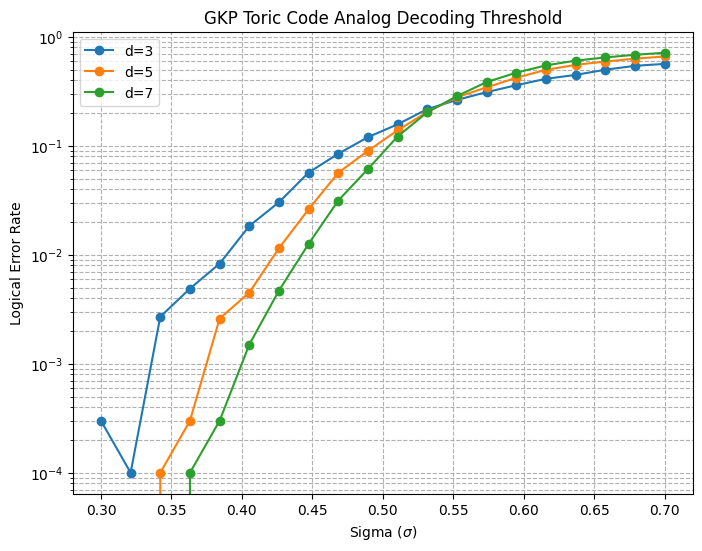

In [4]:
sigma_vals = np.linspace(0.3, 0.7, 20)
distances = [3, 5, 7]

plt.figure(figsize=(8, 6))

for d in distances:
    rates = gkp_toric_qubit_only(d, sigma_vals, n_trials=10000)
    plt.plot(sigma_vals, rates, marker='o', label=f'd={d}')

plt.yscale('log')
plt.xlabel(r"Sigma ($\sigma$)")
plt.ylabel("Logical Error Rate")
plt.title("GKP Toric Code Analog Decoding Threshold")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

this plots the standard deviation of the physical error against the logiacl error rate

to convert this to physical error rates we use the continuous gaussian error equation thing 

$$ p = 1 - \int_{-\sqrt{\pi}/2}^{\sqrt{\pi}/2} \frac{1}{\sqrt{2\pi\sigma^2}} e ^ \frac{-x^2}{2\sigma^2} dx $$

the scipy.special.erf fucntion can be used to simplify this 

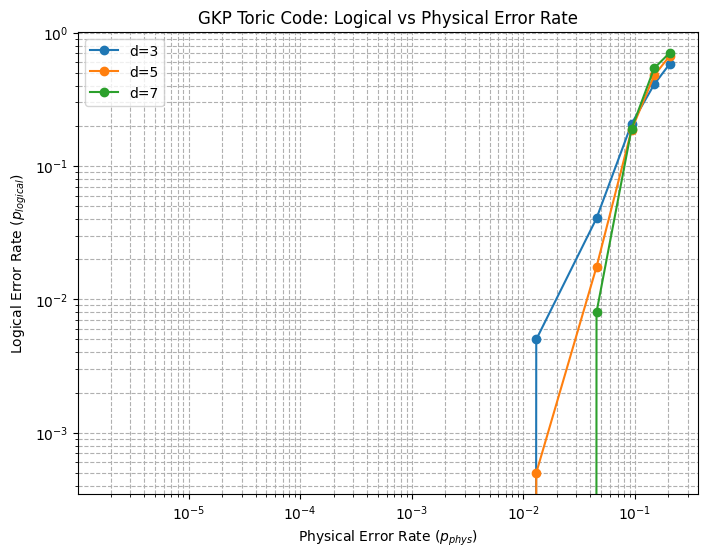

In [5]:
from scipy.special import erf

def sigma_to_physical_p(sigma):
    return 1 - erf(np.sqrt(np.pi) / (2 * np.sqrt(2) * sigma))

sigma_vals = np.linspace(0.1, 0.7, 8)

physical_probs = sigma_to_physical_p(sigma_vals)

plt.figure(figsize=(8, 6))

for d in distances:
    #print(f"\nSimulating d={d}...")
    rates = gkp_toric_qubit_only(d, sigma_vals, n_trials=2000)

    plt.plot(physical_probs, rates, marker='o', label=f'd={d}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Physical Error Rate ($p_{phys}$)")
plt.ylabel("Logical Error Rate ($p_{logical}$)")
plt.title("GKP Toric Code: Logical vs Physical Error Rate")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Now looking at these but over time, so repettitions of the surface code are done 

For this the measurment also has error and this error value decides if another set of checks is none after the first one

    Trying to use the tutorial and reps like this doesnt seem to work well with the gkp displacement error so it can also be donw manually

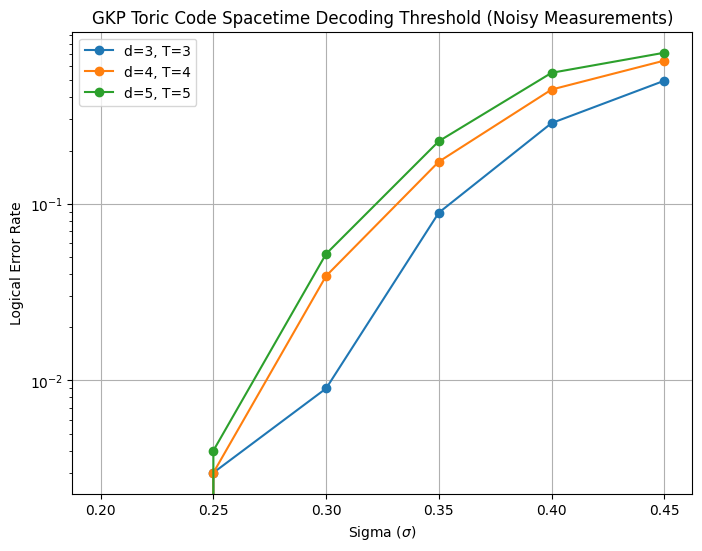

In [20]:
def run_gkp_toric_spacetime_simulation(d, sigma_vals, n_trials=1000):
    Hx = toric_x_stab(d)
    logical_x = toric_logical_x(d)
    num_qubits = Hx.shape[1]
    num_stabilizers = Hx.shape[0]
    T = d 
    
    H_space = kron(eye(T, dtype=np.uint8), Hx)
    I_stab = eye(num_stabilizers, dtype=np.uint8)
    Row_time = []
    for i in range(T):
        row_blocks = []
        for j in range(T):
            if i == j:
                row_blocks.append(I_stab)
            elif i == j + 1:
                row_blocks.append(I_stab)
            else:
                row_blocks.append(csc_matrix((num_stabilizers, num_stabilizers), dtype=np.uint8))
        Row_time.append(hstack(row_blocks))
    H_time = vstack(Row_time)
    
    # spacial and time combine
    H_3D = hstack([H_space, H_time])
    H_3D.data = H_3D.data % 2
    H_3D.eliminate_zeros()
    
    total_space_cols = num_qubits * T

    logical_rates = []

    for sigma in sigma_vals:
        logical_errors = 0

        for _ in range(n_trials):
            all_ep_bits = []
            all_weights = []
            
            # over time qubit noise
            cumulative_ep = np.zeros(num_qubits, dtype=np.uint8)
            for t in range(T):
                dp = np.random.normal(0, sigma, num_qubits)
                sp_vals = ((dp + sqrt_pi / 2) % sqrt_pi) - sqrt_pi / 2
                ep_slice = (np.round((dp - sp_vals) / sqrt_pi).astype(int)) % 2
                
                cumulative_ep = (cumulative_ep + ep_slice) % 2
                all_ep_bits.append(cumulative_ep)
                
                space_w = ((sqrt_pi - np.abs(sp_vals)) ** 2 - sp_vals ** 2) / (2 * sigma ** 2)
                all_weights.append(space_w)
                
            # time meas noise
            for t in range(T):
                meas_dp = np.random.normal(0, sigma, num_stabilizers)
                meas_sp = ((meas_dp + sqrt_pi / 2) % sqrt_pi) - sqrt_pi / 2
                meas_ep = (np.round((meas_dp - meas_sp) / sqrt_pi).astype(int)) % 2
                
                all_ep_bits.append(meas_ep)
                time_w = ((sqrt_pi - np.abs(meas_sp)) ** 2 - meas_sp ** 2) / (2 * sigma ** 2)
                all_weights.append(time_w)
                
            # 1d arrays
            full_error_vector = np.concatenate(all_ep_bits)
            full_weights_vector = np.concatenate(all_weights)
            
            syndrome = (H_3D @ full_error_vector) % 2
            matching = pymatching.Matching.from_check_matrix(H_3D)
            correction = matching.decode(syndrome, weights=full_weights_vector, as_weights=True)
            
            final_true_error = cumulative_ep
            
            final_layer_start = (T - 1) * num_qubits
            final_correction = correction[final_layer_start:final_layer_start + num_qubits]
            
            residual_error = (final_true_error + final_correction) % 2
            if np.any((logical_x @ residual_error) % 2):
                logical_errors += 1

        rate = logical_errors / n_trials
        logical_rates.append(rate)
        
    return logical_rates

sigma_vals = np.linspace(0.2, 0.45, 6)
distances = [3, 4, 5]

plt.figure(figsize=(8, 6))

for d in distances:
    rates = run_gkp_toric_spacetime_simulation(d, sigma_vals, n_trials=1000)
    plt.plot(sigma_vals, rates, marker='o', label=f'd={d}, T={d}')

plt.yscale('log')
plt.xlabel(r"Sigma ($\sigma$)")
plt.ylabel("Logical Error Rate")
plt.title("GKP Toric Code Spacetime Decoding Threshold (Noisy Measurements)")
plt.legend()
plt.grid(True)
plt.show()